In [2]:
# ------------- 包的安装 ---------------------#
# !pip install pandas matplotlib seaborn scikit-learn
# ------------- 调包 --------------------------#
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.datasets import load_iris
from pathlib import Path

In [3]:
# ------------ 数据导入和预处理 -------------------#
# Path 用于建立图片导出目录，避免手动拼接路径字符串
output_dir = Path("./") # './'表示当前工作目录

# 加载 Iris 数据集
iris = load_iris(as_frame=True)
df = iris.frame.copy()
print(df.head())
# 转换后删除原始数值列，仅保留品种名称列以便后续分析
species_map = dict(enumerate(iris.target_names))  # {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df["species"] = df["target"].map(species_map)     # 根据映射替换数值
df = df.drop(columns="target")                    # 移除已无用的数值标签列

print(df.head())

feature_order = [
    "Sepal length",
    "Sepal width",
    "Petal length",
    "Petal width"
]

feature_name_map = {
    "sepal length (cm)": "Sepal length",
    "sepal width (cm)": "Sepal width",
    "petal length (cm)": "Petal length",
    "petal width (cm)": "Petal width"
}

long_df = df.melt(
    id_vars="species",
    value_vars=list(feature_name_map.keys()),
    var_name="feature",
    value_name="value"
)

long_df["feature"] = long_df["feature"].map(feature_name_map)

summary_df = (
    long_df
    .groupby(["species", "feature"], as_index=False)
    .agg(mean_value=("value", "mean"))
)

print(summary_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4 

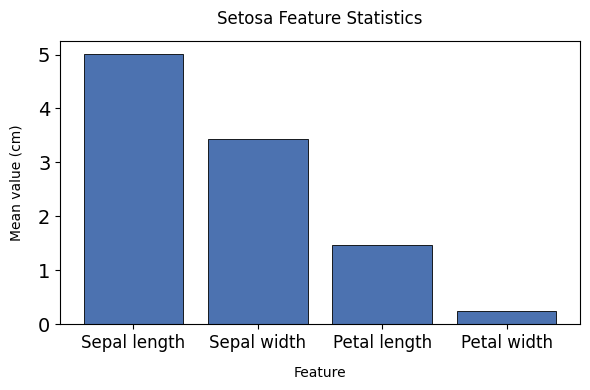

In [4]:
# -----------------  全局样式优化前的绘图 -----------------#
one_species = "setosa"

plot_df = (
    summary_df[summary_df["species"] == one_species]
    .set_index("feature")
    .loc[feature_order]
    .reset_index()
)

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    plot_df["feature"],
    plot_df["mean_value"],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Setosa Feature Statistics", pad=12)
ax.set_xlabel("Feature", labelpad=10)
ax.set_ylabel("Mean value (cm)", labelpad=10)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=14)

plt.tight_layout()
plt.savefig(output_dir / "01_setosa_before_global_style.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# -------------- 全局参数 -----------------#
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",

    "font.size": 12,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,

    "xtick.minor.size": 0,
    "ytick.minor.size": 3,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
    "xtick.minor.width": 1,
    "ytick.minor.width": 1,

    "axes.grid": False,
    "axes.edgecolor": "gray",
    "axes.linewidth": 1,
    "axes.spines.left": True,
    "axes.spines.right": True,
    "axes.spines.top": True,
    "axes.spines.bottom": True,

    "mathtext.default": "it",
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False
})

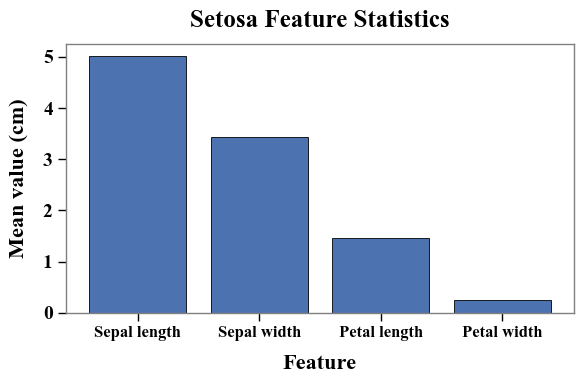

In [6]:
# ------------- 绘制单个子图 -----------------------#
# ---------- 数据准备阶段 ----------
# 指定要绘制的品种
one_species = "setosa"

# 从汇总表中筛选该品种的数据，并调整行索引顺序
plot_df = (
    summary_df[summary_df["species"] == one_species]  # 筛选出 setosa 品种的行
    .set_index("feature")                             # 将 "feature" 列设为行索引
    .loc[feature_order]                               # 按预设的特征顺序（花萼长/宽、花瓣长/宽）重新排序行
    .reset_index()                                    # 将行索引重置为普通列，还原数据框格式
)

# ---------- 创建画布 ----------
# fig: 整个图形窗口；ax: 单个坐标系（axes）对象
fig, ax = plt.subplots(figsize=(6, 4))  # 宽6英寸，高4英寸

# ---------- 绘制柱状图 ----------
bar_color = "#4C72B0"  # 定义统一柱子颜色（十六进制蓝色）

# ax.bar() 返回的是一个 BarContainer 对象，包含所有柱子的集合
bars = ax.bar(
    plot_df["feature"],      # x轴数据：四个特征的名称
    plot_df["mean_value"],   # y轴数据：对应的平均值
    color=bar_color,         # 柱子填充色
    edgecolor="black",       # 柱子边框颜色
    linewidth=0.6            # 柱子边框粗细
)

# ---------- 设置标题与轴标签 ----------
ax.set_title("Setosa Feature Statistics", pad=12,size=18)  # pad=12 表示标题与绘图区域顶部之间的间距;size=18 表示标题字号
ax.set_xlabel("Feature", labelpad=10)              # labelpad 控制轴标签与刻度标签的距离
ax.set_ylabel("Mean value (cm)", labelpad=10)

# ---------- 调整刻度样式 ----------
# tick_params() 专门控制刻度线和刻度标签的外观
ax.tick_params(axis="x", labelsize=12)             # x轴：刻度标签字号12
ax.tick_params(axis="y", labelsize=14)             # y轴：刻度标签字号14（刻度线沿用全局默认长度）

# ---------- 自动调整布局并显示 ----------
plt.tight_layout()  # 自动调整子图参数，使标签和标题不被裁切
plt.savefig(output_dir / "02_setosa_global_style.png", dpi=300, bbox_inches="tight")
plt.show()

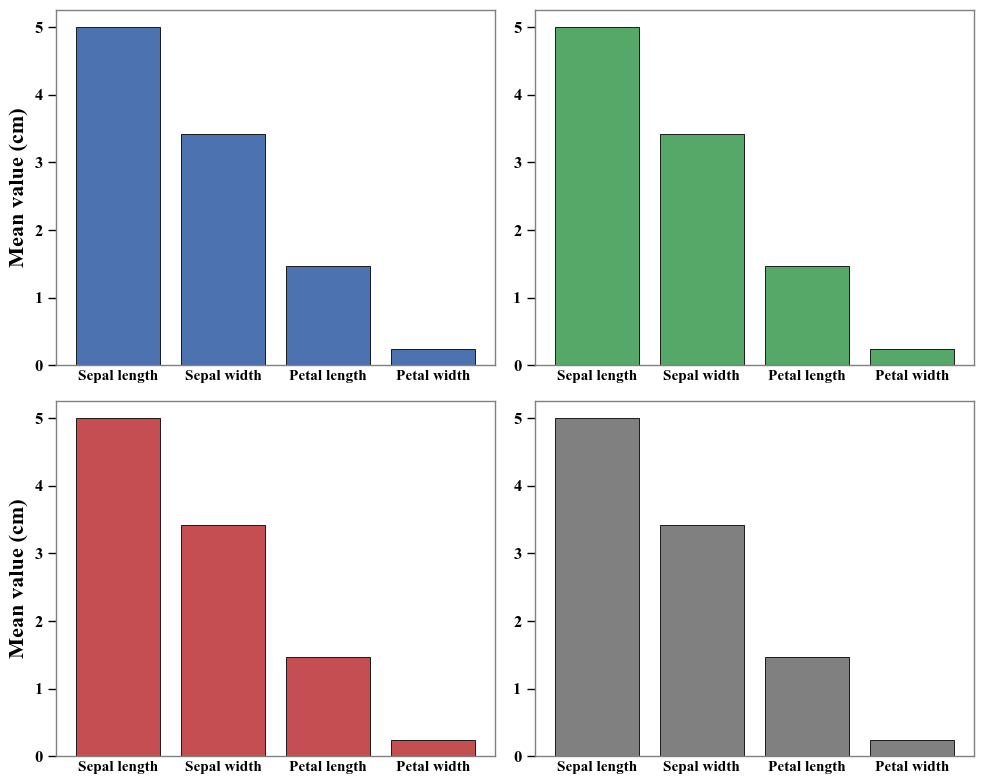

In [7]:
# 四种颜色方案预览
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

colors = ["#4C72B0", "#55A868", "#C44E52", "gray"]

for idx, ax in enumerate(axes):
    bars = ax.bar(
        plot_df["feature"],
        plot_df["mean_value"],
        color=colors[idx],
        edgecolor="black",
        linewidth=0.6
    )
    ax.set_title('', pad=10, fontsize=12)
    ax.set_ylabel("Mean value (cm)" if idx == 0 or idx == 2 else "")
    ax.tick_params(axis="x", length=0, labelsize=11)
    ax.tick_params(axis="y", labelsize=12)

plt.tight_layout()
plt.savefig(output_dir / "03_setosa_color_options.png", dpi=300, bbox_inches="tight")
plt.show()

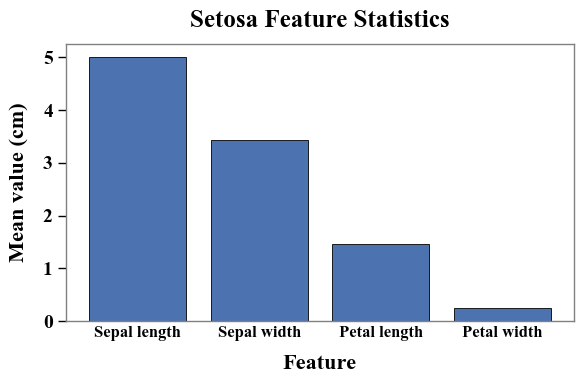

In [8]:
# ------------- 刻度线调整 ------------#
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    plot_df["feature"],
    plot_df["mean_value"],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.6
)


ax.set_title("Setosa Feature Statistics", pad=12, size=18)
ax.set_xlabel("Feature", labelpad=10)
ax.set_ylabel("Mean value (cm)", labelpad=10)

ax.tick_params(axis="x", length=0, labelsize=12)
ax.tick_params(axis="y", length=6, width=1, labelsize=14)

plt.tight_layout()
plt.savefig(output_dir / "04_setosa_tick_params.png", dpi=300, bbox_inches="tight") # 图片自动调整布局并导出
plt.show()

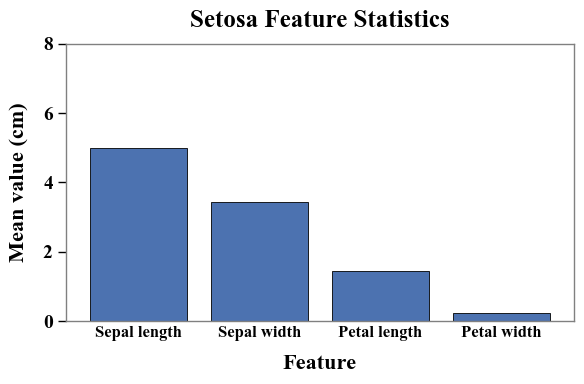

In [9]:
#----------------坐标轴范围调整 --------------#
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    plot_df["feature"],
    plot_df["mean_value"],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Setosa Feature Statistics", pad=12, size=18)
ax.set_xlabel("Feature", labelpad=10)
ax.set_ylabel("Mean value (cm)", labelpad=10)

ax.set_ylim(0, 8)
ax.set_xlim(-0.6, len(feature_order) - 0.4)

ax.tick_params(axis="x", length=0, labelsize=12)
ax.tick_params(axis="y", length=6, width=1, labelsize=14)

plt.tight_layout()
plt.savefig(output_dir / "05_setosa_axis_limits.png", dpi=300, bbox_inches="tight")
plt.show()

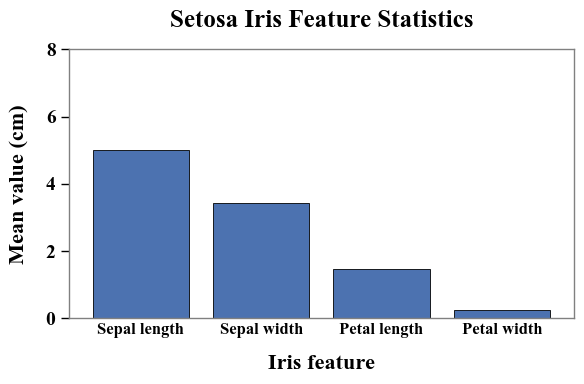

In [10]:
# ------------ 调整标题和轴标题 --------------#
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    plot_df["feature"],
    plot_df["mean_value"],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Setosa Iris Feature Statistics", loc="center", pad=16, size=18)
ax.set_xlabel("Iris feature", labelpad=12)
ax.set_ylabel("Mean value (cm)", labelpad=12)

ax.set_ylim(0, 8)
ax.set_xlim(-0.6, len(feature_order) - 0.4)

ax.tick_params(axis="x", length=0, labelsize=12)
ax.tick_params(axis="y", length=6, width=1, labelsize=14)

plt.tight_layout()
plt.savefig(output_dir / "06_setosa_title_labels.png", dpi=300, bbox_inches="tight")
plt.show()


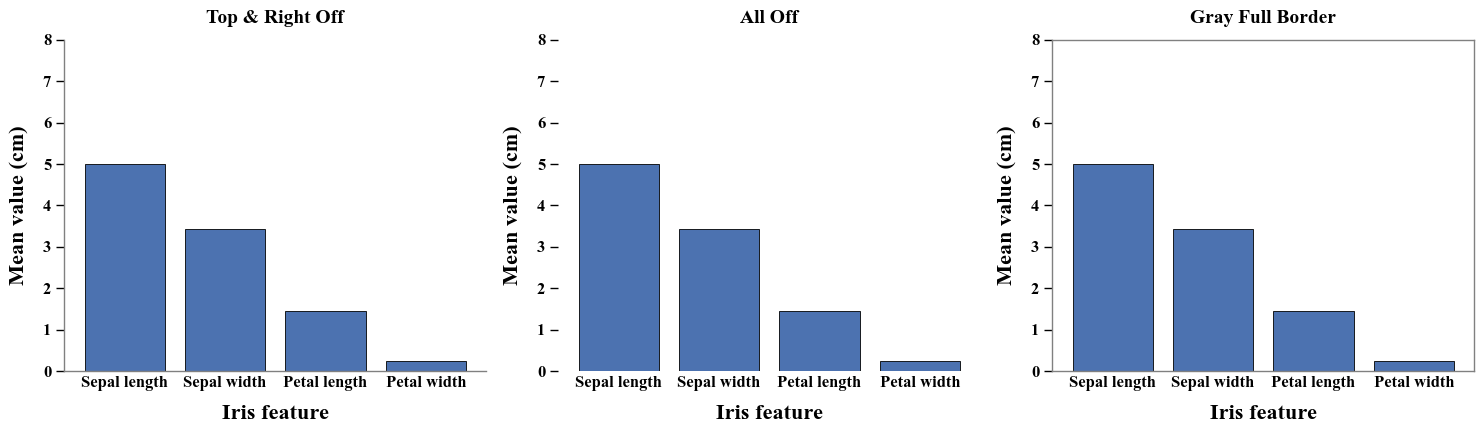

In [11]:
# -------------- 调整边框 --------------#
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ===== 子图 1：去掉上边和右边 =====
ax = axes[0]
ax.bar(plot_df["feature"], plot_df["mean_value"], color="#4C72B0", edgecolor="black", linewidth=0.6)
ax.set_title("Top & Right Off", fontsize=14, pad=12)
ax.set_xlabel("Iris feature", labelpad=10)
ax.set_ylabel("Mean value (cm)", labelpad=10)
ax.set_ylim(0, 8)
ax.set_xlim(-0.6, len(feature_order) - 0.4)
ax.tick_params(axis="x", length=0, labelsize=12)
ax.tick_params(axis="y", length=6, width=1, labelsize=12)
ax.spines["top"].set_visible(False)      # 去掉上边
ax.spines["right"].set_visible(False)    # 去掉右边

# ===== 子图 2：全部去掉 =====
ax = axes[1]
ax.bar(plot_df["feature"], plot_df["mean_value"], color="#4C72B0", edgecolor="black", linewidth=0.6)
ax.set_title("All Off", fontsize=14, pad=12)
ax.set_xlabel("Iris feature", labelpad=10)
ax.set_ylabel("Mean value (cm)", labelpad=10)
ax.set_ylim(0, 8)
ax.set_xlim(-0.6, len(feature_order) - 0.4)
ax.tick_params(axis="x", length=0, labelsize=12)
ax.tick_params(axis="y", length=6, width=1, labelsize=12)
for spine in ax.spines.values():
    spine.set_visible(False)              # 四条边全隐藏

# ===== 子图 3：保留全部边框，但设为灰色、线宽 1 =====
ax = axes[2]
ax.bar(plot_df["feature"], plot_df["mean_value"], color="#4C72B0", edgecolor="black", linewidth=0.6)
ax.set_title("Gray Full Border", fontsize=14, pad=12)
ax.set_xlabel("Iris feature", labelpad=10)
ax.set_ylabel("Mean value (cm)", labelpad=10)
ax.set_ylim(0, 8)
ax.set_xlim(-0.6, len(feature_order) - 0.4)
ax.tick_params(axis="x", length=0, labelsize=12)
ax.tick_params(axis="y", length=6, width=1, labelsize=12)
for spine in ax.spines.values():
    spine.set_color("gray")               # 颜色变灰
    spine.set_linewidth(1)                # 线宽调细

# ---------- 自动调整布局并显示 ----------
plt.tight_layout()
plt.savefig(output_dir / "07_border_styles_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

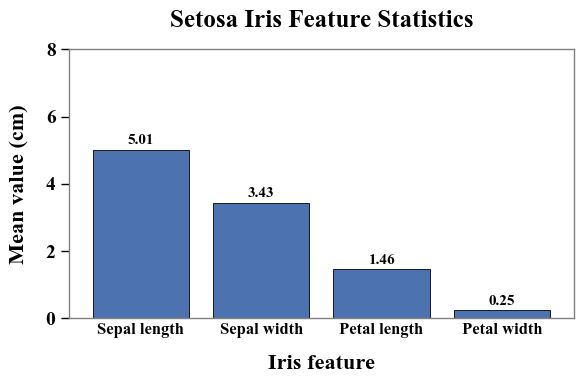

In [12]:
# -------------- 添加柱顶数值 -------------#
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    plot_df["feature"],
    plot_df["mean_value"],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.6
)

# 在每个柱子的正上方添加数值标签，显示该柱的精确高度（保留两位小数）
for bar in bars:
    height = bar.get_height()
    ax.text(
        # 水平居中：柱子左边缘 + 半宽
        bar.get_x() + bar.get_width() / 2,  
        # 垂直位置：顶部上方留出 0.08 的间距，避免与柱顶重叠
        height + 0.08,                      

        # 生成柱顶显示的文字：开头的 f 表示“这是一个能填变量的文本”，
        # 里面的 {height} 会被替换成真实的高度数值，
        # 冒号后面的 .2f 表示“固定保留两位小数”（f 代表小数，.2 代表两位）。
        f"{height:.2f}",                    

        # 水平对齐：居中
        ha="center", 
        # 垂直对齐：文本底部对齐指定坐标，确保文字从该点向上绘制                       
        va="bottom",                        
        fontsize=11,
        fontweight="bold"
    )

ax.set_title("Setosa Iris Feature Statistics", loc="center", pad=16, size=18)
ax.set_xlabel("Iris feature", labelpad=12)
ax.set_ylabel("Mean value (cm)", labelpad=12)

ax.set_ylim(0, 8)
ax.set_xlim(-0.6, len(feature_order) - 0.4)

ax.tick_params(axis="x", length=0, labelsize=12)
ax.tick_params(axis="y", length=6, width=1, labelsize=14)

for spine in ax.spines.values():
    spine.set_color("gray")
    spine.set_linewidth(1)

plt.tight_layout()
plt.savefig(output_dir / "07_setosa_single_color_optimized.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# ------------- 颜色分配 ---------------#
palette = sns.color_palette("deep", n_colors=len(feature_order))
color_map = dict(zip(feature_order, palette))
bar_colors = [color_map[feature] for feature in plot_df["feature"]]

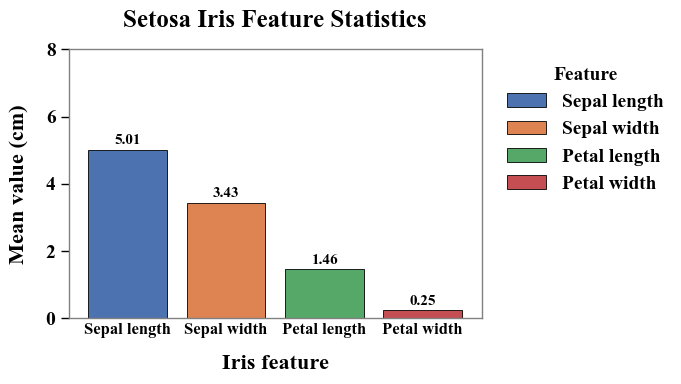

In [16]:
# ------------- 自动图例 ----------#
palette = sns.color_palette("deep", n_colors=len(feature_order))
color_map = dict(zip(feature_order, palette))
bar_colors = [color_map[feature] for feature in plot_df["feature"]]

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    plot_df["feature"],
    plot_df["mean_value"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6,
    label=feature_order  # 让每根柱子按顺序带上自己的特征名
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.08,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title("Setosa Iris Feature Statistics", loc="center", pad=16, size=18)
ax.set_xlabel("Iris feature", labelpad=12)
ax.set_ylabel("Mean value (cm)", labelpad=12)

ax.set_ylim(0, 8)
ax.set_xlim(-0.6, len(feature_order) - 0.4)

ax.tick_params(axis="x", length=0, labelsize=12)
ax.tick_params(axis="y", length=6, width=1, labelsize=14)

for spine in ax.spines.values():
    spine.set_color("gray")
    spine.set_linewidth(1)

# 自动图例：不传 handles，Matplotlib 会从带 label 的柱子中收集图例条目
# 图例绘制函数的细节详见3.3.2节，此处仅用作展示

ax.legend(
    title="Feature",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title_fontsize=14
)

plt.tight_layout()
plt.savefig(output_dir / "08_setosa_feature_colors.png", dpi=300, bbox_inches="tight")
plt.show()

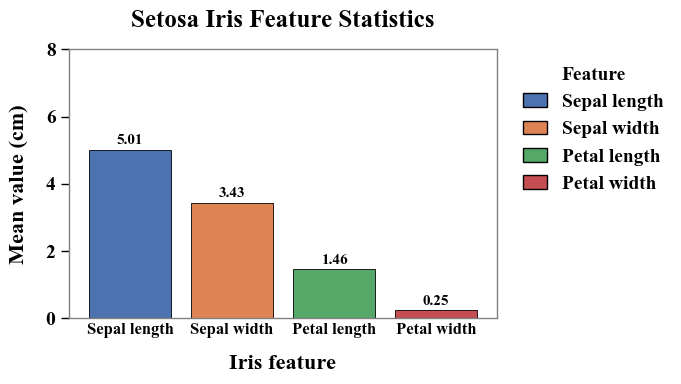

In [17]:
#------------- 手动图例 -----------#
palette = sns.color_palette("deep", n_colors=len(feature_order))
color_map = dict(zip(feature_order, palette))
bar_colors = [color_map[feature] for feature in plot_df["feature"]]

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    plot_df["feature"],
    plot_df["mean_value"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.08,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title("Setosa Iris Feature Statistics", loc="center", pad=16, size=18)
ax.set_xlabel("Iris feature", labelpad=12)
ax.set_ylabel("Mean value (cm)", labelpad=12)

ax.set_ylim(0, 8)
ax.set_xlim(-0.6, len(feature_order) - 0.4)

ax.tick_params(axis="x", length=0, labelsize=12)
ax.tick_params(axis="y", length=6, width=1, labelsize=14)

for spine in ax.spines.values():
    spine.set_color("gray")
    spine.set_linewidth(1)

# 创建图例
legend_handles = [
    Patch(
        facecolor=color_map[feature],
        edgecolor="black",
        label=feature
    )
    for feature in feature_order
]

# 绘制图例
ax.legend(
    handles=legend_handles,      # 使用手动创建的图例条目
    title="Feature",             # 图例标题
    frameon=False,               # 不显示图例外框
    bbox_to_anchor=(1.02, 1),     # 将图例放到坐标轴右侧
    loc="upper left",            # 图例左上角对齐到锚点
    title_fontsize=14,
    handlelength=1.2,            # 控制色块长度
    labelspacing=0.5             # 控制图例条目之间的距离
)

plt.tight_layout()
plt.savefig(output_dir / "08_setosa_feature_colors2.png", dpi=300, bbox_inches="tight")
plt.show()

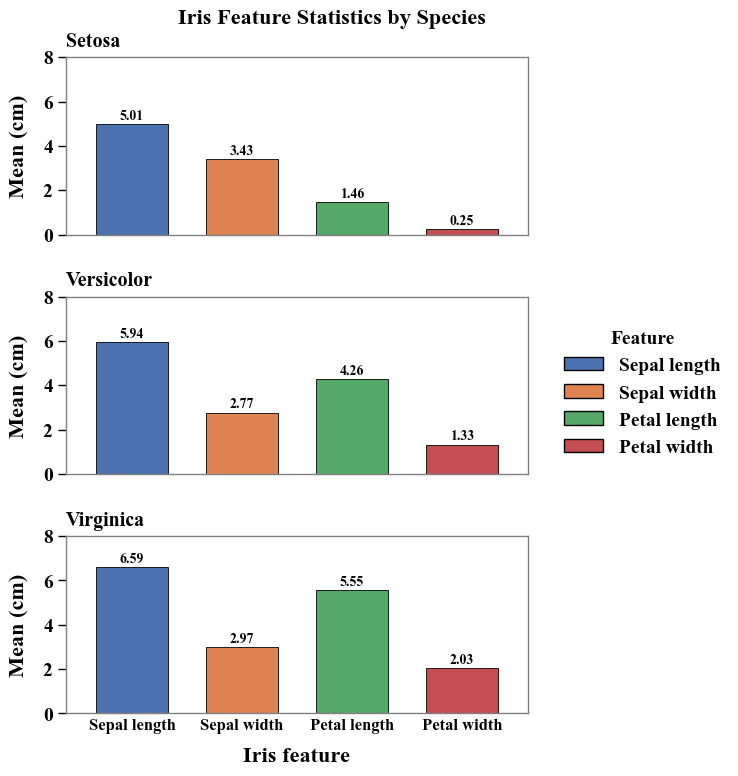

In [18]:
# ------------ 纵向组合图 --------------#
species_order = ["setosa", "versicolor", "virginica"]

palette = sns.color_palette("deep", n_colors=len(feature_order))
color_map = dict(zip(feature_order, palette))
legend_handles = [
    Patch(facecolor=color_map[feature], edgecolor="black", label=feature)  # Patch 用于创建图例色块
    for feature in feature_order
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(7, 8),
    sharex=True,  # 所有子图共用 x 轴，避免重复显示不必要的信息
    sharey=True   # 所有子图共用 y 轴，方便直接比较柱高
)

for ax, species in zip(axes, species_order):  # zip 将每个子图 ax 与一个品种名称配对
    sub_df = (
        summary_df[summary_df["species"] == species]
        .set_index("feature")
        .loc[feature_order]
        .reset_index()
    )

    bar_colors = [color_map[feature] for feature in sub_df["feature"]]

    bars = ax.bar(
        sub_df["feature"],
        sub_df["mean_value"],
        color=bar_colors,
        edgecolor="black",
        linewidth=0.6,
        width=0.65
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.08,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_title(species.capitalize(), loc="left", pad=8)
    ax.set_ylabel("Mean (cm)", labelpad=10)
    ax.set_ylim(0, 8)
    ax.set_xlim(-0.6, len(feature_order) - 0.4)

    ax.tick_params(axis="x", length=0, labelsize=12)
    ax.tick_params(axis="y", length=6, width=1, labelsize=14)

    for spine in ax.spines.values():
        spine.set_color("gray")
        spine.set_linewidth(1)

axes[-1].set_xlabel("Iris feature", labelpad=10)  # axes[-1] 表示最后一个子图，只在底部显示 x 轴标题

fig.suptitle(
    "Iris Feature Statistics by Species",
    y=0.98,  # y 控制总标题在整张图中的纵向位置
    fontsize=16,
    fontweight="bold"
)

fig.legend(
    handles=legend_handles,
    title="Feature",
    frameon=False,
    loc="center right",        # 图例自身的锚定位置
    bbox_to_anchor=(1.08, 0.5), # 图例相对于整张图的位置
    title_fontsize=14
)

fig.subplots_adjust(
    left=0.12,    # 左边界
    right=0.78,   # 右边界，给右侧图例留空间
    top=0.92,     # 顶部边界，给总标题留空间
    bottom=0.10,  # 底部边界，给 x 轴标题留空间
    hspace=0.35   # 子图之间的纵向间距
)

plt.savefig(output_dir / "09_iris_species_vertical_facets.png", dpi=300, bbox_inches="tight")
plt.show()

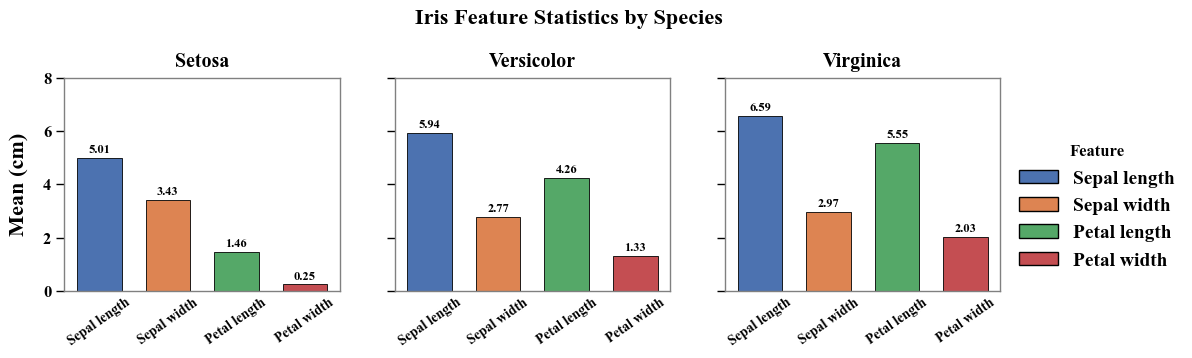

In [19]:
# ---------------- 横向组合 --------------#
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(12, 3.8),
    sharex=True,
    sharey=True
)

for ax, species in zip(axes, species_order):
    sub_df = (
        summary_df[summary_df["species"] == species]
        .set_index("feature")
        .loc[feature_order]
        .reset_index()
    )

    bar_colors = [color_map[feature] for feature in sub_df["feature"]]

    bars = ax.bar(
        sub_df["feature"],
        sub_df["mean_value"],
        color=bar_colors,
        edgecolor="black",
        linewidth=0.6,
        width=0.65
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.08,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    ax.set_title(species.capitalize(), pad=8)
    ax.set_ylim(0, 8)
    ax.tick_params(axis="x", length=0, labelsize=10, rotation=35) # rotation = 35 轴标签旋转35°
    ax.tick_params(axis="y", length=6, width=1, labelsize=12)

    for spine in ax.spines.values():
        spine.set_color("gray")
        spine.set_linewidth(1)

axes[0].set_ylabel("Mean (cm)", labelpad=10)  # 横向排布时，只给最左侧子图添加 y 轴标题

fig.suptitle(
    "Iris Feature Statistics by Species",
    y=1.02,
    fontsize=16,
    fontweight="bold"
)

fig.legend(
    handles=legend_handles,
    title="Feature",
    frameon=False,
    loc="center right",
    bbox_to_anchor=(1.02, 0.5),
    title_fontsize=12
)

fig.subplots_adjust(
    left=0.08,
    right=0.86,
    bottom=0.28,
    top=0.84,
    wspace=0.20  # 子图之间的横向间距
)

plt.savefig(output_dir / "10_iris_species_horizontal_facets.png", dpi=300, bbox_inches="tight")
plt.show()